In [68]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("content/lichess_db_puzzle.csv.zst")

In [4]:
df.shape

(5311149, 10)

In [5]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1103,74,88,598,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN


In [10]:
df["Themes"] = df["Themes"].str.split(" ")
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,"[crushing, hangingPiece, long, middlegame]",https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,"[advantage, endgame, short]",https://lichess.org/F8M8OS71#53,NaN
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1340,77,91,726,"[advantage, endgame, rookEndgame, short]",https://lichess.org/MQSyb3KW#127,NaN
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1103,74,88,598,"[advantage, middlegame, short]",https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,"[crushing, endgame, fork, short]",https://lichess.org/au2lCK5o#73,NaN


In [11]:
df = df.explode("Themes")

In [12]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,hangingPiece,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,long,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,middlegame,https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,advantage,https://lichess.org/F8M8OS71#53,NaN


In [19]:
grouped = df.groupby("Themes").count().reset_index()

In [20]:
grouped.head()

,Themes,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,GameUrl,OpeningTags
0,advancedPawn,325702,325702,325702,325702,325702,325702,325702,325702,11482
1,advantage,1554316,1554316,1554316,1554316,1554316,1554316,1554316,1554316,446758
2,anastasiaMate,6215,6215,6215,6215,6215,6215,6215,6215,635
3,arabianMate,6122,6122,6122,6122,6122,6122,6122,6122,154
4,attackingF2F7,37653,37653,37653,37653,37653,37653,37653,37653,32091


In [77]:
grouped[grouped["Themes"].str.contains("promotion")]

,Themes,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,GameUrl,OpeningTags
45,promotion,125432,125432,125432,125432,125432,125432,125432,125432,1415


In [39]:
themes_list = [
    "fork", 
    "pin", 
    "promotion", 
    "skewer", 
    "backRankMate",
    "discoveredAttack",
    "trappedPiece",
    "capturingDefender",
    "smotheredMate",
    "zugzwang"
    ]

In [41]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,crushing,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,hangingPiece,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,long,https://lichess.org/787zsVup/black#48,NaN
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1800,77,95,8421,middlegame,https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1492,74,96,33381,advantage,https://lichess.org/F8M8OS71#53,NaN


In [42]:
only_set_themes = df[df["Themes"].isin(themes_list)]
only_set_themes.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,77,100,168,fork,https://lichess.org/au2lCK5o#73,NaN
13,000o3,8/2p1k3/6p1/1p1P1p2/1P3P2/3K2Pp/7P/8 b - - 1 43,e7d6 d3d4 g6g5 f4g5,946,77,87,182,zugzwang,https://lichess.org/BAY91mF3/black#86,NaN
14,000qP,8/7R/8/5p2/4bk1P/8/2r2K2/6R1 w - - 7 51,f2f1 f4f3 f1e1 c2c1 e1d2 c1g1,2052,79,92,917,skewer,https://lichess.org/r4xUR6fC#101,NaN
15,000rO,3R4/8/K7/pB2b3/1p6/1P2k3/3p4/8 w - - 4 58,a6a5 e5c7 a5b4 c7d8,1110,82,85,69,fork,https://lichess.org/tzeeBEc2#115,NaN
18,0017R,r2qk2r/pp2ppbp/1n1p2p1/3Pn3/2P5/2NBBP1P/PP3P2/...,e5c4 d3c4 b6c4 d1a4 d8d7 a4c4,1694,75,96,3618,fork,https://lichess.org/ol84k0z4/black#24,Alekhine_Defense Alekhine_Defense_Other_variat...


In [43]:
set_themes_dropped = only_set_themes.drop(["RatingDeviation", "Popularity", "NbPlays", "GameUrl", "OpeningTags"], axis=1)
set_themes_dropped.head()

,PuzzleId,FEN,Moves,Rating,Themes
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,fork
13,000o3,8/2p1k3/6p1/1p1P1p2/1P3P2/3K2Pp/7P/8 b - - 1 43,e7d6 d3d4 g6g5 f4g5,946,zugzwang
14,000qP,8/7R/8/5p2/4bk1P/8/2r2K2/6R1 w - - 7 51,f2f1 f4f3 f1e1 c2c1 e1d2 c1g1,2052,skewer
15,000rO,3R4/8/K7/pB2b3/1p6/1P2k3/3p4/8 w - - 4 58,a6a5 e5c7 a5b4 c7d8,1110,fork
18,0017R,r2qk2r/pp2ppbp/1n1p2p1/3Pn3/2P5/2NBBP1P/PP3P2/...,e5c4 d3c4 b6c4 d1a4 d8d7 a4c4,1694,fork


In [45]:
set_themes_ohe = pd.get_dummies(set_themes_dropped, columns=["Themes"])
set_themes_ohe.head()

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1425,False,False,False,True,False,False,False,False,False,False
13,000o3,8/2p1k3/6p1/1p1P1p2/1P3P2/3K2Pp/7P/8 b - - 1 43,e7d6 d3d4 g6g5 f4g5,946,False,False,False,False,False,False,False,False,False,True
14,000qP,8/7R/8/5p2/4bk1P/8/2r2K2/6R1 w - - 7 51,f2f1 f4f3 f1e1 c2c1 e1d2 c1g1,2052,False,False,False,False,False,False,True,False,False,False
15,000rO,3R4/8/K7/pB2b3/1p6/1P2k3/3p4/8 w - - 4 58,a6a5 e5c7 a5b4 c7d8,1110,False,False,False,True,False,False,False,False,False,False
18,0017R,r2qk2r/pp2ppbp/1n1p2p1/3Pn3/2P5/2NBBP1P/PP3P2/...,e5c4 d3c4 b6c4 d1a4 d8d7 a4c4,1694,False,False,False,True,False,False,False,False,False,False


In [86]:
back_rank = set_themes_ohe[set_themes_ohe["Themes_backRankMate"]]
capturing_def = set_themes_ohe[set_themes_ohe["Themes_capturingDefender"]]
disc_attack = set_themes_ohe[set_themes_ohe["Themes_discoveredAttack"]]
fork = set_themes_ohe[set_themes_ohe["Themes_fork"]]
pin = set_themes_ohe[set_themes_ohe["Themes_pin"]]
promotion = set_themes_ohe[set_themes_ohe["Themes_promotion"]]
skewer = set_themes_ohe[set_themes_ohe["Themes_skewer"]]
smoth_mate = set_themes_ohe[set_themes_ohe["Themes_smotheredMate"]]
trap_piece = set_themes_ohe[set_themes_ohe["Themes_trappedPiece"]]
zugzwang = set_themes_ohe[set_themes_ohe["Themes_zugzwang"]]

In [87]:
back_rank.head()

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
24,001Wz,4r1k1/5ppp/r1p5/p1n1RP2/8/2P2N1P/2P3P1/3R2K1 b...,e8e5 d1d8 e5e8 d8e8,1120,True,False,False,False,False,False,False,False,False,False
64,0030b,6k1/5ppp/5nb1/pp6/6rP/5N1Q/Pq2r1P1/3R2RK b - -...,g6e4 d1d8 f6e8 d8e8,771,True,False,False,False,False,False,False,False,False,False
71,003Tx,2r5/pR5p/5p1k/4p3/4r3/B4nPP/PP3P2/1K2R3 w - - ...,e1e4 f3d2 b1a1 c8c1,1532,True,False,False,False,False,False,False,False,False,False
87,0042j,3r2k1/4nppp/pq1p1b2/1p2P3/2r2P2/2P1NR2/PP1Q2BP...,d6e5 d2d8 b6d8 d1d8,428,True,False,False,False,False,False,False,False,False,False
88,00465,3r1Q1k/pp4pp/2p5/6q1/5R2/2P5/P1P2PPP/3rR1K1 b ...,d8f8 f4f8,573,True,False,False,False,False,False,False,False,False,False


In [88]:
back_rank_sample = back_rank.sample(n=1000)
capturing_def_sample = capturing_def.sample(n=1000)
disc_attack_sample = disc_attack.sample(n=1000)
fork_sample = fork.sample(n=1000)
pin_sample = pin.sample(n=1000)
promotion_sample = promotion.sample(n=1000)
skewer_sample = skewer.sample(n=1000)
smoth_mate_sample = smoth_mate.sample(n=1000)
trap_piece_sample = trap_piece.sample(n=1000)
zugzwang_sample = zugzwang.sample(n=1000)


In [89]:
back_rank_sample.head()

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
993777,BaxXH,4r1k1/pbq2p1p/1p4p1/3p4/1P1P4/P5Q1/B4PPP/6K1 w...,g3c7 e8e1,601,True,False,False,False,False,False,False,False,False,False
4394717,pJDXu,3r3k/6pp/1Q3p2/p5q1/2Pr2P1/1P1R3P/P7/3R2K1 b -...,d4d3 b6d8 d3d8 d1d8,1335,True,False,False,False,False,False,False,False,False,False
3716474,hPXC3,5rk1/5ppp/pn3r2/2bB4/7q/2N2Q2/1P3PPP/R1BR2K1 w...,f3h3 h4f2 g1h1 f2f1 d1f1 f6f1,1065,True,False,False,False,False,False,False,False,False,False
1945026,Mi8vI,4Q3/6kp/3r1q2/5p2/1P2p3/8/5PPP/3R3K w - - 2 33,d1d6 f6a1 d6d1 a1d1,838,True,False,False,False,False,False,False,False,False,False
842470,9pS01,5r2/4k2p/pq1p1rp1/1p1Qp3/8/P1P1n3/BP2R1PP/4R2K...,e2e3 f6f1 e1f1 f8f1,973,True,False,False,False,False,False,False,False,False,False


In [90]:
back_rank_sample.shape

(1000, 14)

In [91]:
sample_table_list = [
    back_rank_sample,
    capturing_def_sample,
    disc_attack_sample,
    fork_sample,
    pin_sample,
    promotion_sample,
    skewer_sample,
    smoth_mate_sample,
    trap_piece_sample,
    zugzwang_sample
]

In [92]:
mini_puzzle_table = pd.concat(sample_table_list, axis=0)
mini_puzzle_table.head()

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
993777,BaxXH,4r1k1/pbq2p1p/1p4p1/3p4/1P1P4/P5Q1/B4PPP/6K1 w...,g3c7 e8e1,601,True,False,False,False,False,False,False,False,False,False
4394717,pJDXu,3r3k/6pp/1Q3p2/p5q1/2Pr2P1/1P1R3P/P7/3R2K1 b -...,d4d3 b6d8 d3d8 d1d8,1335,True,False,False,False,False,False,False,False,False,False
3716474,hPXC3,5rk1/5ppp/pn3r2/2bB4/7q/2N2Q2/1P3PPP/R1BR2K1 w...,f3h3 h4f2 g1h1 f2f1 d1f1 f6f1,1065,True,False,False,False,False,False,False,False,False,False
1945026,Mi8vI,4Q3/6kp/3r1q2/5p2/1P2p3/8/5PPP/3R3K w - - 2 33,d1d6 f6a1 d6d1 a1d1,838,True,False,False,False,False,False,False,False,False,False
842470,9pS01,5r2/4k2p/pq1p1rp1/1p1Qp3/8/P1P1n3/BP2R1PP/4R2K...,e2e3 f6f1 e1f1 f8f1,973,True,False,False,False,False,False,False,False,False,False


In [93]:
mini_puzzle_table.shape

(10000, 14)

In [94]:
mini_puzzle_table.groupby("PuzzleId").count().reset_index().sort_values("FEN")

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
0,00AhO,1,1,1,1,1,1,1,1,1,1,1,1,1
6658,fX8dd,1,1,1,1,1,1,1,1,1,1,1,1,1
6659,fXUDI,1,1,1,1,1,1,1,1,1,1,1,1,1
6660,fXner,1,1,1,1,1,1,1,1,1,1,1,1,1
6661,fXyCe,1,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1193,7sAcO,2,2,2,2,2,2,2,2,2,2,2,2,2
5149,W754T,2,2,2,2,2,2,2,2,2,2,2,2,2
1022,6aJok,2,2,2,2,2,2,2,2,2,2,2,2,2
900,5le82,2,2,2,2,2,2,2,2,2,2,2,2,2


In [98]:
mini_puzzle_table_combine = mini_puzzle_table.groupby("PuzzleId").max().reset_index()

In [99]:
mini_puzzle_table_combine.groupby("PuzzleId").count().reset_index().sort_values("FEN")

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
0,00AhO,1,1,1,1,1,1,1,1,1,1,1,1,1
6659,fXUDI,1,1,1,1,1,1,1,1,1,1,1,1,1
6660,fXner,1,1,1,1,1,1,1,1,1,1,1,1,1
6661,fXyCe,1,1,1,1,1,1,1,1,1,1,1,1,1
6662,fYBL0,1,1,1,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,KrEha,1,1,1,1,1,1,1,1,1,1,1,1,1
3334,KriDC,1,1,1,1,1,1,1,1,1,1,1,1,1
3335,Krrex,1,1,1,1,1,1,1,1,1,1,1,1,1
3328,KpcR4,1,1,1,1,1,1,1,1,1,1,1,1,1


In [100]:
mini_puzzle_table_combine[mini_puzzle_table_combine["PuzzleId"] == "nY8YF"]

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
7961,nY8YF,4b1k1/1Qr2pp1/2Nq1n1p/3P4/8/r5P1/5PBP/2RR2K1 w...,b7b8 c7c6 d5c6 d6b8 c6c7 b8c8 g2b7 c8b7,1674,False,True,True,False,False,False,False,False,False,False


In [102]:
mini_puzzle_table_combine.head()

,PuzzleId,FEN,Moves,Rating,Themes_backRankMate,Themes_capturingDefender,Themes_discoveredAttack,Themes_fork,Themes_pin,Themes_promotion,Themes_skewer,Themes_smotheredMate,Themes_trappedPiece,Themes_zugzwang
0,00AhO,r1b2rk1/2q2p1p/1p2pbp1/pP6/2P1Q3/P2B1N2/5PPP/3...,e4a8 c8b7 a8a7 f8a8 a7a8 b7a8,1281,False,False,False,False,False,False,False,False,True,False
1,00Kia,5r1k/4n1pp/1p6/pP5Q/P2pB2K/6P1/2P4P/4q3 b - - ...,g7g6 h5e5 h8g8 e4d5 e7d5 e5e1,1666,False,False,False,True,False,False,False,False,False,False
2,00YbG,8/7p/3k2p1/p5P1/P2K4/8/8/8 b - - 4 47,d6c6 d4c4 c6d6 c4b5,1787,False,False,False,False,False,False,False,False,False,True
3,01F1N,r4rk1/pp1q2pp/3p1p2/2p1nP2/5Q2/2P4P/PP1N1PP1/4...,e5d3 f4c4 d6d5 c4d3,1177,False,False,False,True,False,False,False,False,False,False
4,01HAa,r1bq3r/1np1k1b1/pp1p3p/3Pp2B/2P1Pp1Q/2N5/PP1N2...,e7d7 h4g4 d7e7 g4g7,1934,False,False,False,True,False,False,False,False,False,False


<Axes: ylabel='Frequency'>

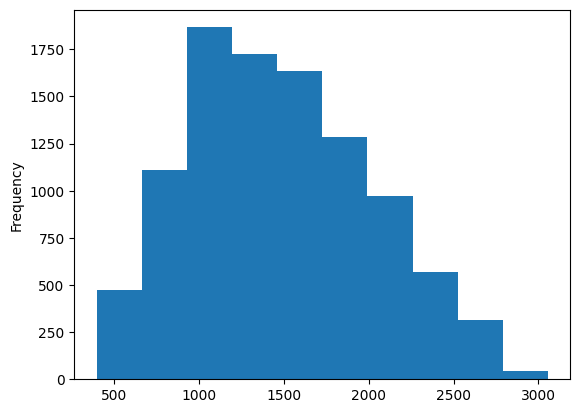

In [104]:
mini_puzzle_table_combine["Rating"].plot(kind="hist", stacked=True)

In [106]:
mini_puzzle_table_combine.to_csv("./content/mini-puzzles.csv", index=False)